In [ ]:
!pip install wordcloud nltk

```
wordcloud_generator
----------------------
Generates a word cloud from text data by analyzing word frequencies.

Original intent: Visualize the most-used words from personal ChatGPT export data.
Fallback dataset: Jane Austen's "Emma" from the NLTK Gutenberg corpus.

Dependencies:
    pip install nltk wordcloud matplotlib
```



In [ ]:
import nltk
from nltk.corpus import gutenberg
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import re
from collections import Counter

In [ ]:
# Download the Gutenberg corpus if not already present
# Contains classic literary texts including works by Austen, Shakespeare, etc.
nltk.download('gutenberg')

# ── 1. Load text ──────────────────────────────────────────────────────────────
# Using Jane Austen's "Emma" as a stand-in for ChatGPT export data.
# To use your own data, replace this with:
#   with open('your_chat_export.txt', 'r') as f:
#       text = f.read()
text = gutenberg.raw('austen-emma.txt')

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.


In [ ]:
# ── 2. Normalize ──────────────────────────────────────────────────────────────
# Lowercase everything so "The" and "the" are counted as the same word
text = text.lower()

# Strip punctuation and digits — keep only alphabet characters and whitespace
text = re.sub(r'[^a-z\s]', '', text)

In [ ]:
# ── 3. Filter stopwords ───────────────────────────────────────────────────────
# STOPWORDS is a built-in set from wordcloud (e.g. "the", "a", "is", "and")
# These are high-frequency but low-meaning words we don't want dominating the cloud
stopwords = set(STOPWORDS)

words = text.split()
filtered_words = [w for w in words if w not in stopwords]

In [ ]:
# ── 4. Count word frequencies ─────────────────────────────────────────────────
# Counter produces a dict-like object: { 'word': count, ... }
word_counts = Counter(filtered_words)

# top 10 most common words
print(word_counts.most_common(10))

[('mr', 1124), ('emma', 751), ('mrs', 687), ('miss', 587), ('must', 567), ('will', 555), ('much', 474), ('said', 474), ('one', 428), ('every', 427)]


In [ ]:
# ── 5. Generate and display the word cloud ────────────────────────────────────
# Word size in the cloud is proportional to frequency
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate_from_frequencies(word_counts)

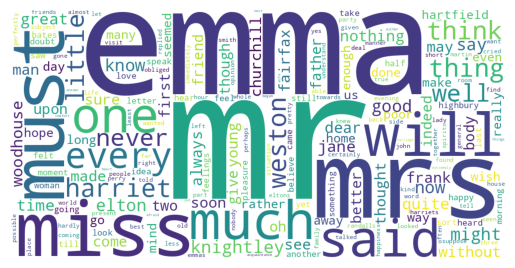

In [ ]:
plt.imshow(wordcloud)
plt.axis("off")  # Hide axis ticks/labels — not meaningful for a word cloud
plt.show()